In [47]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# Load Ratings Dataset 
ratings = pd.read_csv(
    "../data/u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

# display first few row
ratings.head()

,user_id,item_id,rating,timestamp
0,0,50,5,881250949
1,0,172,5,881250949
2,0,133,1,881250949
3,196,242,3,881250949
4,186,302,3,891717742


In [49]:
# Load Movies Titles 
movies = pd.read_csv("../data/Movie_Id_Titles")

# display first few rows
movies.head()

,item_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [51]:
# Merge Both Datasets 
data = pd.merge(ratings, movies, on="item_id")

data.head()

,user_id,item_id,rating,timestamp,title
0,0,50,5,881250949,Star Wars (1977)
1,0,172,5,881250949,"Empire Strikes Back, The (1980)"
2,0,133,1,881250949,Gone with the Wind (1939)
3,196,242,3,881250949,Kolya (1996)
4,186,302,3,891717742,L.A. Confidential (1997)


In [52]:
#Check  number of rows and columns in Dataset
data.shape

(100003, 5)

In [53]:
# 10 Most Rated Movies
data.groupby("title")["rating"].count().sort_values(ascending=False).head(10)

title
Star Wars (1977)                 584
Contact (1997)                   509
Fargo (1996)                     508
Return of the Jedi (1983)        507
Liar Liar (1997)                 485
English Patient, The (1996)      481
Scream (1996)                    478
Toy Story (1995)                 452
Air Force One (1997)             431
Independence Day (ID4) (1996)    429
Name: rating, dtype: int64

In [54]:
# 10 Average Movie Ratings
data.groupby("title")["rating"].mean().sort_values(ascending=False).head(10)

title
Aiqing wansui (1994)                                 5.0
Entertaining Angels: The Dorothy Day Story (1996)    5.0
Santa with Muscles (1996)                            5.0
Prefontaine (1997)                                   5.0
They Made Me a Criminal (1939)                       5.0
Saint of Fort Washington, The (1993)                 5.0
Great Day in Harlem, A (1994)                        5.0
Star Kid (1997)                                      5.0
Marlene Dietrich: Shadow and Light (1996)            5.0
Someone Else's America (1995)                        5.0
Name: rating, dtype: float64

In [55]:
# Movie Ratings Statistics
movie_ratings = data.groupby("title")["rating"].agg(["mean", "count"])
movie_ratings.head()

,mean,count
title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


In [56]:
# Rename Columns 
movie_ratings.rename(columns={"mean": "avg_rating", "count": "num_ratings"}, inplace=True)

movie_ratings.head()


,avg_rating,num_ratings
title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


In [57]:
# Most Popular Movies
movie_ratings.sort_values("num_ratings", ascending=False).head(10)

,avg_rating,num_ratings
title,,
Star Wars (1977),4.359589,584
Contact (1997),3.803536,509
Fargo (1996),4.155512,508
Return of the Jedi (1983),4.007890,507
Liar Liar (1997),3.156701,485
"English Patient, The (1996)",3.656965,481
Scream (1996),3.441423,478
Toy Story (1995),3.878319,452
Air Force One (1997),3.631090,431


<Axes: title={'center': 'Top Rated Movies'}, xlabel='Movies', ylabel='Average Ratings'>

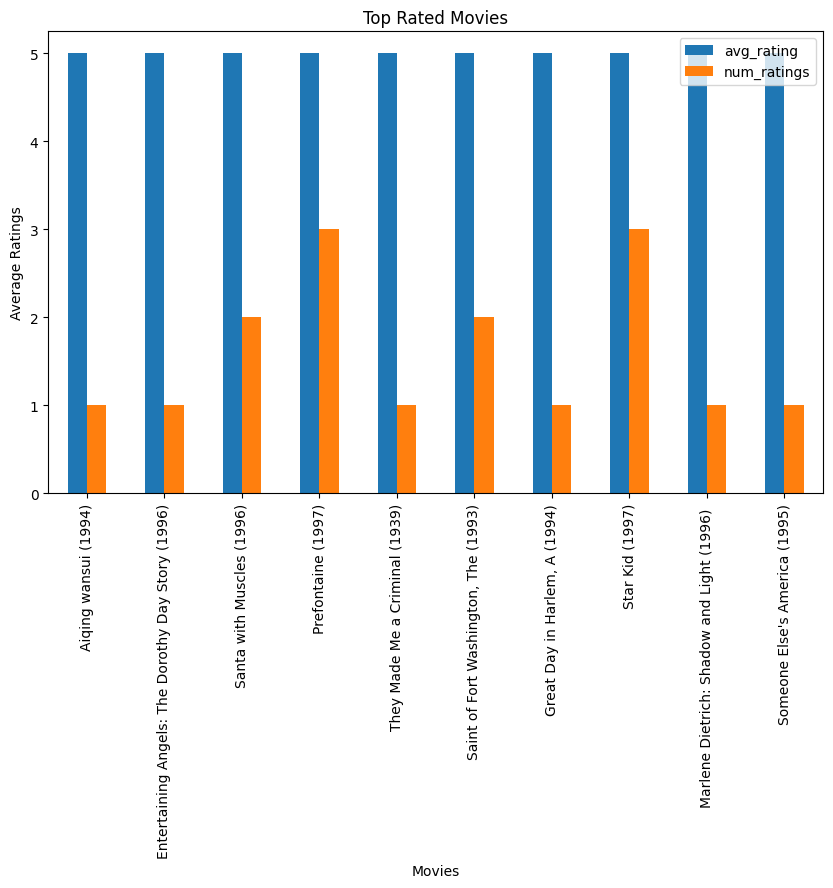

In [58]:
# Visualization (Top Rated Movies)
movie_ratings.sort_values("avg_rating", ascending=False).head(10).plot(
    kind="bar", figsize=(10,6), title="Top Rated Movies" , xlabel="Movies" , ylabel="Average Ratings"
)


<Axes: title={'center': 'Most Rated Movies'}, xlabel='Movies', ylabel='Number of Ratings'>

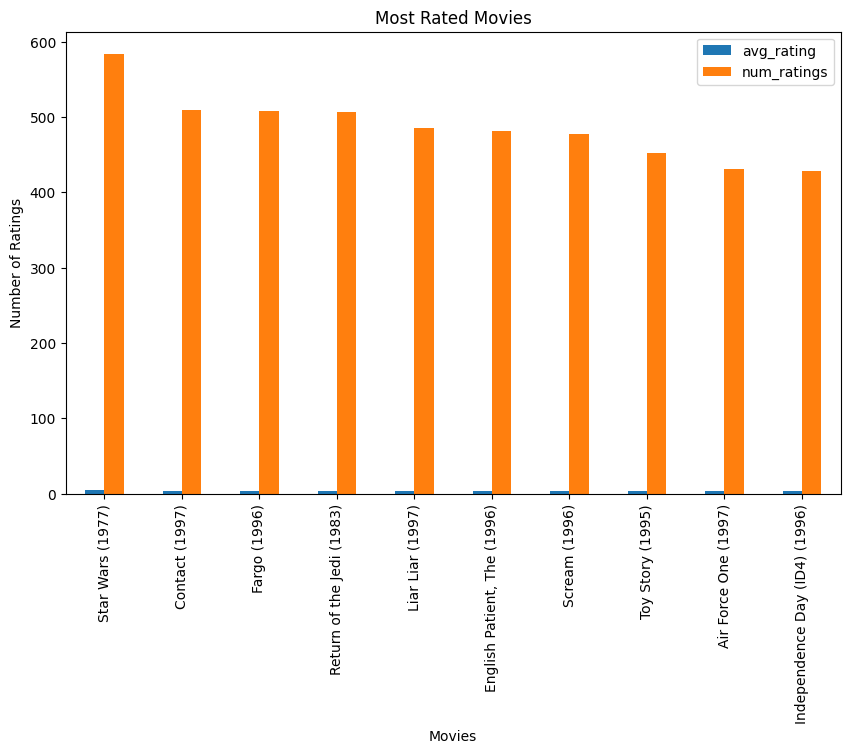

In [59]:
# visualization (Most Rated Movies)
movie_ratings.sort_values("num_ratings", ascending=False).head(10).plot(
    kind="bar", figsize=(10,6), title="Most Rated Movies" , xlabel="Movies" , ylabel="Number of Ratings"
)

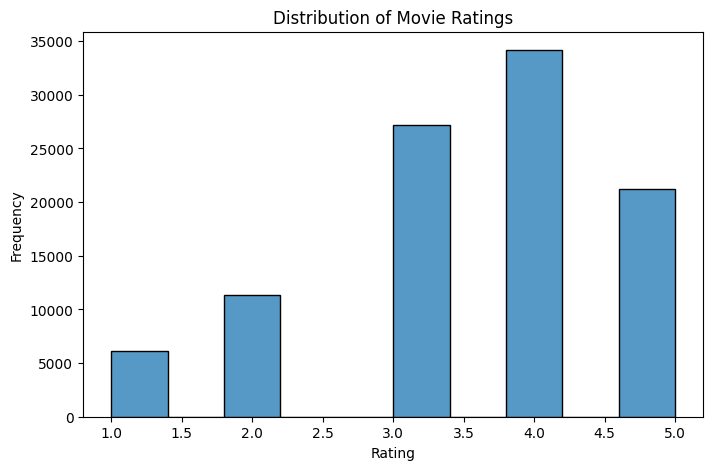

In [60]:
# Visualization (Movies Ratings Distibution)
plt.figure(figsize=(8,5))
sns.histplot(data["rating"], bins=10)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

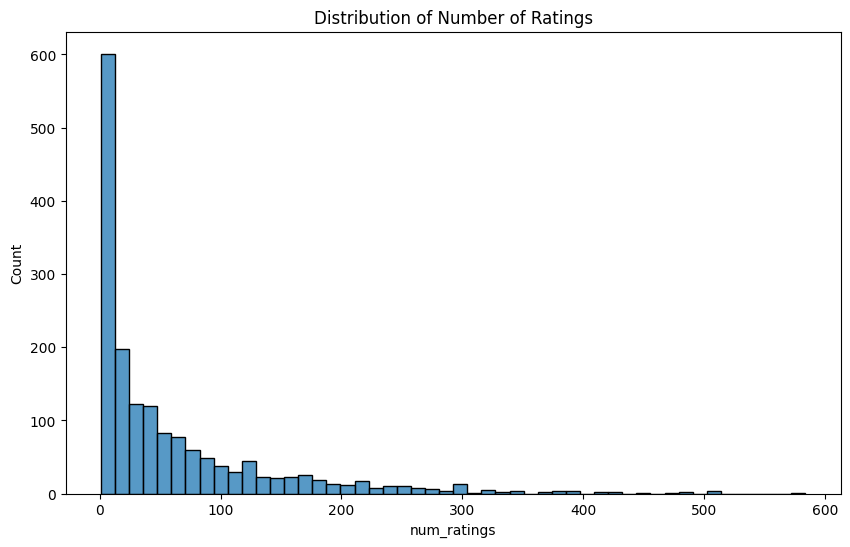

In [61]:
# Visualization (Ratings Count Distribution)
plt.figure(figsize=(10,6))
sns.histplot(movie_ratings["num_ratings"], bins=50)
plt.title("Distribution of Number of Ratings")
plt.show()

In [62]:
# Create Pivot Table
movie_matrix = data.pivot_table(index="user_id", columns="title", values="rating")

movie_matrix.head()

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


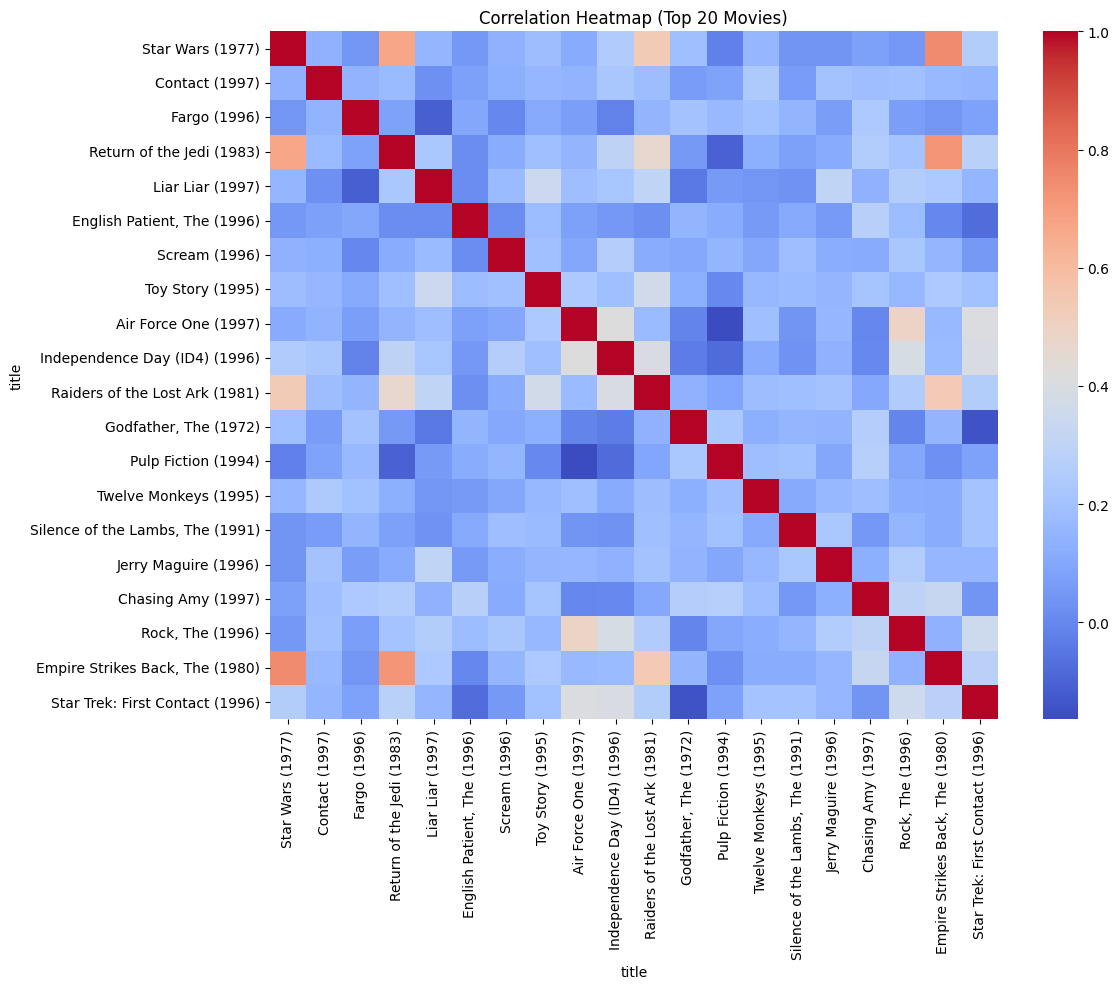

In [63]:
# Select top 20 most rated movies
top_movies = movie_ratings.sort_values("num_ratings", ascending=False).head(20).index

# Create correlation matrix for these movies
corr_matrix = movie_matrix[top_movies].corr()

# Visualize correlation between top movies using heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)

plt.title("Correlation Heatmap (Top 20 Movies)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [64]:
# Select ratings of a specific movie 
toy_story_ratings = movie_matrix["Toy Story (1995)"]
toy_story_ratings.head()

user_id
0    NaN
1    5.0
2    4.0
3    NaN
4    NaN
Name: Toy Story (1995), dtype: float64

In [65]:
# Compute correlation of selected movie with all other movies
similar_movies = movie_matrix.corrwith(toy_story_ratings)
similar_movies.head()

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


title
'Til There Was You (1997)    0.534522
1-900 (1994)                      NaN
101 Dalmatians (1996)        0.232118
12 Angry Men (1957)          0.334943
187 (1997)                   0.651857
dtype: float64

In [66]:
# Convert correlation results into DataFrame
corr_toy_story = pd.DataFrame(similar_movies, columns=["correlation"])

# Remove movies with no correlation data
corr_toy_story.dropna(inplace=True)
corr_toy_story.head()

,correlation
title,
'Til There Was You (1997),0.534522
101 Dalmatians (1996),0.232118
12 Angry Men (1957),0.334943
187 (1997),0.651857
2 Days in the Valley (1996),0.162728


In [67]:
# Join correlation data with rating counts
corr_toy_story = corr_toy_story.join(movie_ratings["num_ratings"])
corr_toy_story.head()

,correlation,num_ratings
title,,
'Til There Was You (1997),0.534522,9
101 Dalmatians (1996),0.232118,109
12 Angry Men (1957),0.334943,125
187 (1997),0.651857,41
2 Days in the Valley (1996),0.162728,93


In [68]:
# Filter movies with sufficient ratings and sort by similarity
recommendations = corr_toy_story[corr_toy_story["num_ratings"] > 100].sort_values("correlation", ascending=False)
recommendations.head()

,correlation,num_ratings
title,,
Toy Story (1995),1.000000,452
"Craft, The (1996)",0.549100,104
Down Periscope (1996),0.457995,101
Miracle on 34th Street (1994),0.456291,101
G.I. Jane (1997),0.454756,175


In [69]:
# Define function to recommend similar movies
def recommend_movies(movie_name):

    if movie_name not in movie_matrix.columns:
        return "Movie not found in dataset"

    movie_ratings_series = movie_matrix[movie_name]

    similar_movies = movie_matrix.corrwith(movie_ratings_series)

    corr_df = pd.DataFrame(similar_movies, columns=["correlation"])
    corr_df.dropna(inplace=True)

    corr_df = corr_df.join(movie_ratings["num_ratings"])

    recommendations = corr_df[corr_df["num_ratings"] > 100].sort_values("correlation", ascending=False)
    
    return recommendations.drop(movie_name).head(10)

In [70]:
# Test recommendation system with different movies
recommend_movies("Toy Story (1995)")

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,correlation,num_ratings
title,,
"Craft, The (1996)",0.549100,104
Down Periscope (1996),0.457995,101
Miracle on 34th Street (1994),0.456291,101
G.I. Jane (1997),0.454756,175
Amistad (1997),0.449915,124
Beauty and the Beast (1991),0.442960,202
"Mask, The (1994)",0.432855,129
Cinderella (1950),0.428372,129
That Thing You Do! (1996),0.427936,176


In [73]:
# Test recommendation system with multiple movies
recommend_movies("Star Wars (1977)")
recommend_movies("Fargo (1996)")
recommend_movies("Toy Story (1995)")

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\Users\hp\AppData\Local\Programs\Python\Python3

,correlation,num_ratings
title,,
"Craft, The (1996)",0.549100,104
Down Periscope (1996),0.457995,101
Miracle on 34th Street (1994),0.456291,101
G.I. Jane (1997),0.454756,175
Amistad (1997),0.449915,124
Beauty and the Beast (1991),0.442960,202
"Mask, The (1994)",0.432855,129
Cinderella (1950),0.428372,129
That Thing You Do! (1996),0.427936,176
